# Questão 1

--- Informações Extraídas ---
Quantização: 16 bits
Total de amostras no arquivo: 21958
Taxa de Amostragem: 8012 Hz, Período de Amostragem: 0.00012481278082875687 s


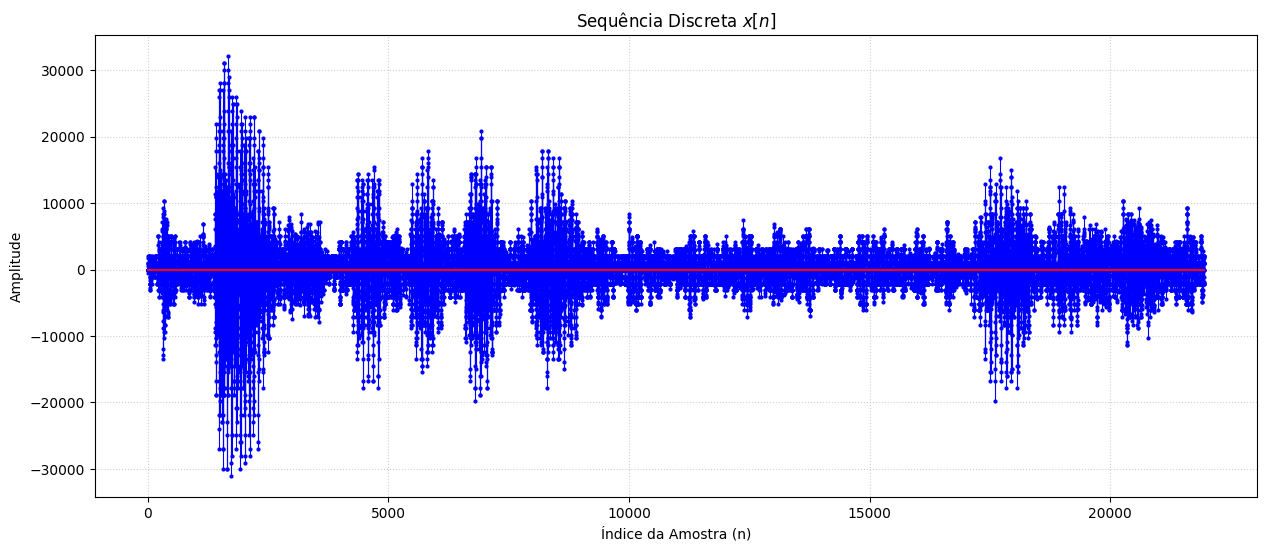

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

NOME_ARQUIVO = '../data/forcewithyou.wav'


try:
    samplerate, data = wavfile.read(NOME_ARQUIVO)

    if len(data.shape) > 1:
        data = data[:, 0]

    # 2. Extrair informações
    bits_quantizacao = data.dtype.itemsize * 8
    num_amostras_total = data.shape[0]
    
    inicio = 0
    fim = data.shape[0]
    n_fragmento = np.arange(inicio, fim)
    data_fragmento = data[inicio:fim]


    x_n = {
        'x': data,
        'N': data.shape[0],
        'Resolution': bits_quantizacao,
        'fs': samplerate,
        'ts': 1/samplerate
    }
    
    print(f"--- Informações Extraídas ---")
    print(f"Quantização: {x_n['Resolution']} bits")
    print(f"Total de amostras no arquivo: {x_n['N']}")
    print(f"Taxa de Amostragem: {x_n['fs']} Hz, Período de Amostragem: {x_n['ts']} s")

    def plot_x_n(x_n, i, f, title):
        plt.figure(figsize=(15, 6))
        
        markerline, stemlines, baseline = plt.stem(np.arange(i, f), x_n['x'], 
                                                linefmt='b-', markerfmt='.', basefmt='r-')
        
        plt.setp(stemlines, 'linewidth', 0.8)
        plt.setp(markerline, 'markersize', 4)
        
        plt.title(title)
        plt.xlabel("Índice da Amostra (n)")
        plt.ylabel("Amplitude")
        plt.grid(True, linestyle=':', alpha=0.6)
        
    
    plot_x_n(x_n, 0, x_n['N'], f"Sequência Discreta $x[n]$")
    plt.show()

except FileNotFoundError:
    print(f"Arquivo '{NOME_ARQUIVO}' não encontrado.")

# Questão 2

## (a)

128


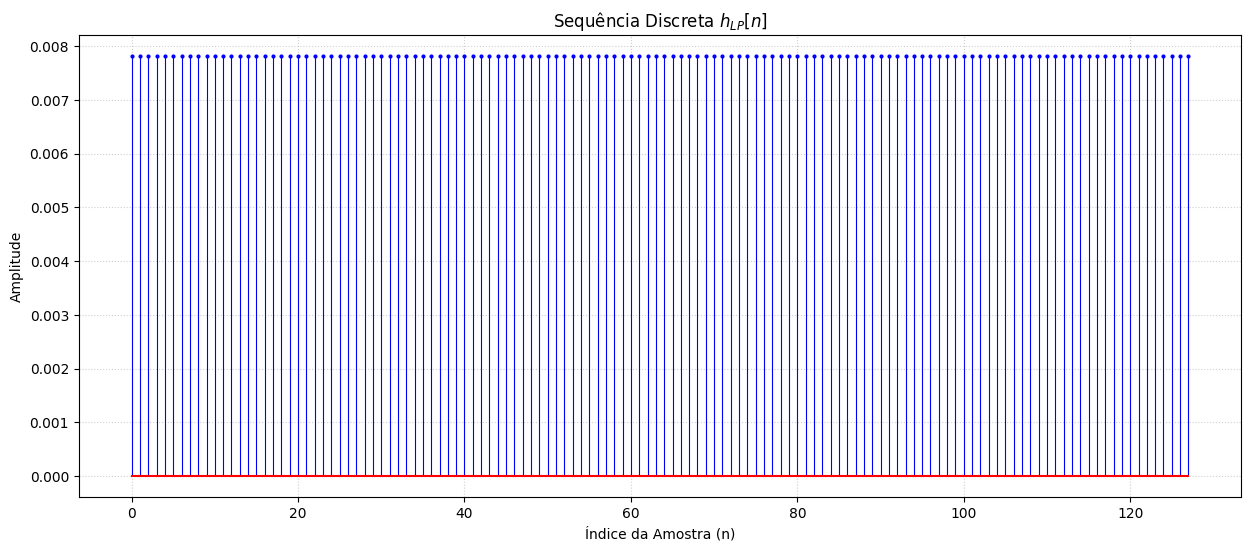

In [24]:
M = 128
h_lp_n = np.ones(M) * (1/M)
print(len(h_lp_n))

h_lp_n = {
    'x': h_lp_n,
    'N': M,
    'Resolution': bits_quantizacao,
    'fs': samplerate,
    'ts': 1/samplerate
}

plot_x_n(h_lp_n, 0, h_lp_n['N'], "Sequência Discreta $h_{LP}[n]$")
plt.show()


## (b)

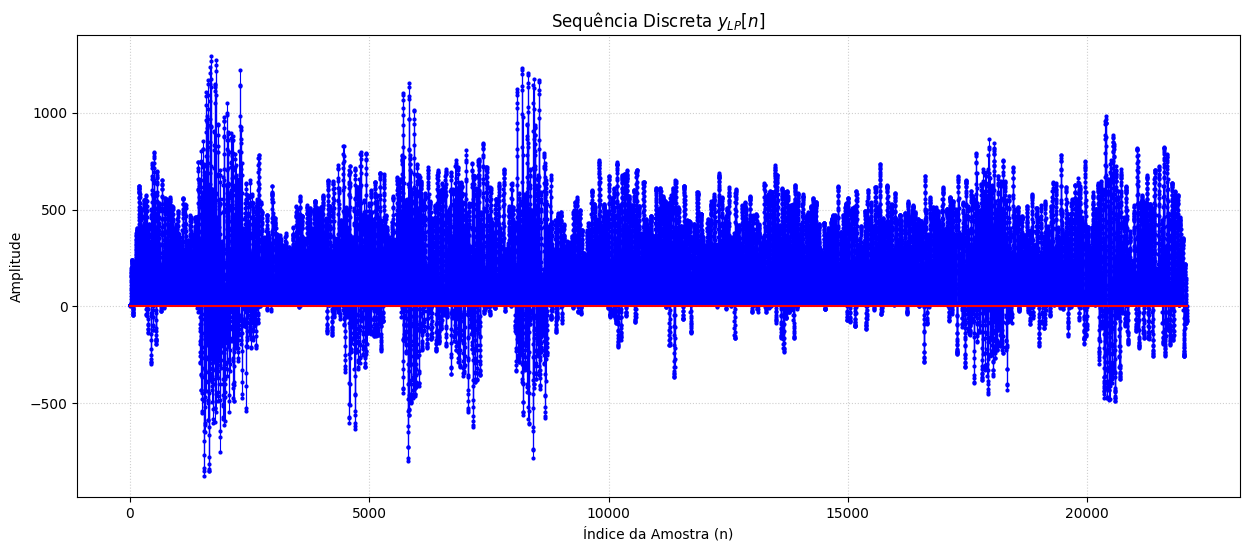

In [25]:
def conv_linear(x_n, h_n):
    y_n = []
    for n in range( x_n['N'] + h_n['N'] - 1 ):
        soma = 0
        for l in range( x_n['N'] ):
            if 0 <= n-l < M - 1:
                soma+= x_n['x'][l] * h_n['x'][n-l]
            else:
                soma+=0
        
        y_n.append(soma)
    y_n = np.array(y_n)
    y_n = {
        'x': y_n,
        'N': x_n['N'] + h_n['N'] - 1,
        'Resolution': bits_quantizacao,
        'fs': samplerate,
        'ts': 1/samplerate 
    }
    return y_n

y_lp_n = conv_linear(x_n, h_lp_n)

plot_x_n(y_lp_n, 0, y_lp_n['N'], "Sequência Discreta $y_{LP}[n]$")
plt.show()

## (c)

In [ ]:
def salvar_x_n(x_n, nome_arquivo="x_n.wav"):
    """
    Recebe o dicionário e salva um arquivo .wav
    """

    sinal = x_n['x']
    fs = x_n['fs']

    max_val = np.max(np.abs(sinal))
    
    if max_val > 0:
        sinal_normalizado = sinal / max_val
    else:
        sinal_normalizado = sinal

    sinal_int16 = (sinal_normalizado * 32767).astype(np.int16)

    wavfile.write(nome_arquivo, fs, sinal_int16)
    print(f"Sucesso! Arquivo '{nome_arquivo}' salvo com {x_n['N']} amostras.")

salvar_x_n(y_lp_n, "../data/forcewithyou_lp.wav")

Sucesso! Arquivo '../data/forcewithyou_lp.wav' salvo com 22085 amostras.


## (d)

128


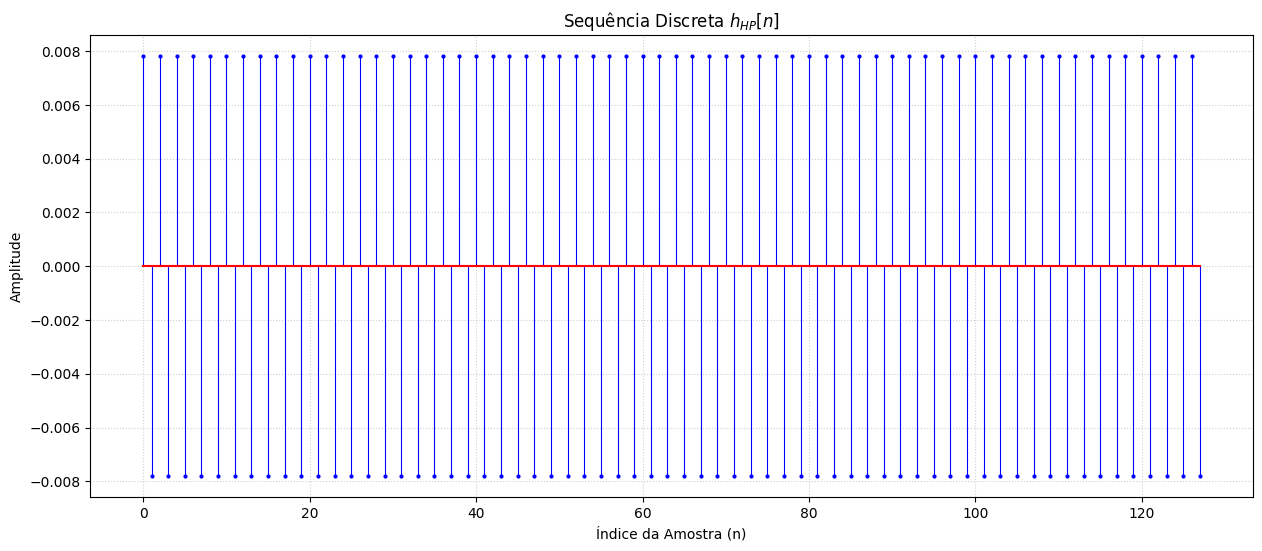

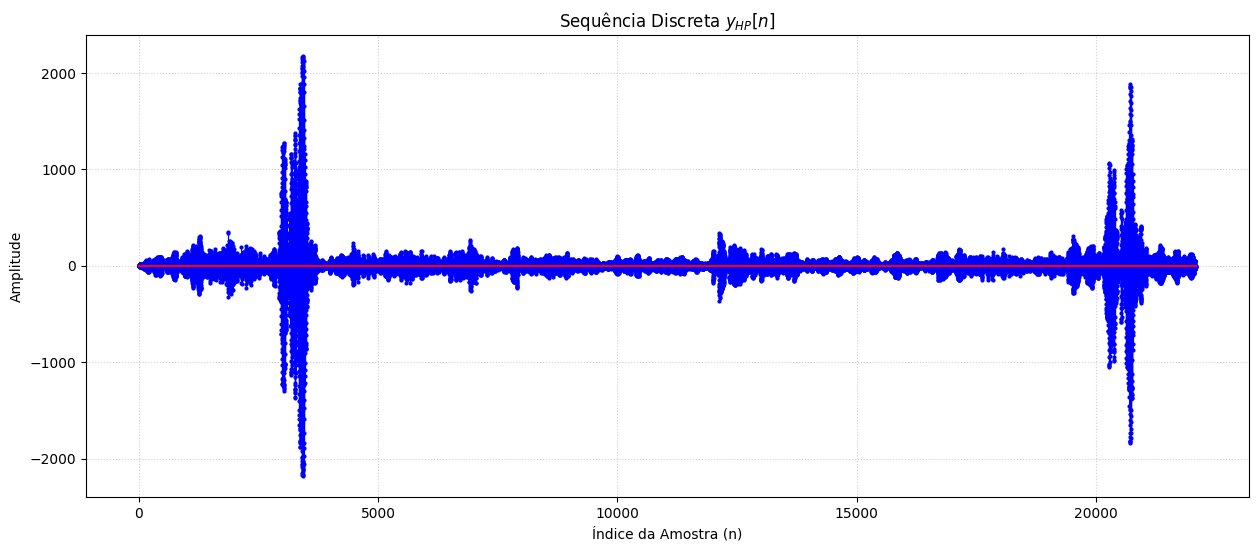

Sucesso! Arquivo '../data/forcewithyou_hp.wav' salvo com 22085 amostras.


In [30]:
M = 128
h_hp_n = np.array([((-1)**n) * h_lp_n['x'][n] for n in range(M)])
print(len(h_hp_n))

h_hp_n = {
    'x': h_hp_n,
    'N': M,
    'Resolution': bits_quantizacao,
    'fs': samplerate,
    'ts': 1/samplerate
}

plot_x_n(h_hp_n, 0, h_hp_n['N'], "Sequência Discreta $h_{HP}[n]$")
plt.show()

y_hp_n = conv_linear(x_n, h_hp_n)
plot_x_n(y_hp_n, 0, y_hp_n['N'], "Sequência Discreta $y_{HP}[n]$")
plt.show()

salvar_x_n(y_hp_n, "../data/forcewithyou_hp.wav")